In [1]:
import numpy as np

# 1. On fixe la graine aléatoire pour avoir les mêmes résultats
np.random.seed(42) # le hasard est le même à chaque lancer du script
n_samples = 100 # taille de l'échantillon
n_features = 2 # nombre de facteurs prédictifs

# 2. Génération d'une matrice X (100 lignes, 2 colonnes/facteurs)
X = np.random.randn(n_samples, n_features)

# 3. On ajoute une colonne de 1 pour l'intercept (la constante beta_0)
X_b = np.c_[np.ones((n_samples, 1)), X] 

# 4. Les vrais coefficients beta théoriques que notre code devra retrouver
true_beta = np.array([[4.5], [3.0], [1.2]])

# 5. Génération de la cible Y avec un bruit gaussien (epsilon)
Y = X_b.dot(true_beta) + np.random.randn(n_samples, 1)

print("Données générées avec succès !")
print("Forme de X_b :", X_b.shape)
print("Forme de Y :", Y.shape)


# A retenir pour Quant : 

# 1. Ne pas utiliser np.random.seed() (Le piège de l'état global)
# --> Cette méthode est dite "legacy" (obsolète) dans NumPy
# --> Elle modifie l'état aléatoire global de toute ton application Python. 
# --> Si un autre script s'exécute en parallèle sur le même serveur, les deux codes vont interférer, brisant la reproductibilité.

# Solution :
# np.random.default_rng()
# --> plus rapide, plus sûr, et cela isole tes simulations 
# --> indispensable pour les simulations de Monte Carlo massives


# 2. Privilégier la clarté de construction matricielle plutôt que les raccourcis syntaxiques
# --> Le problème en production : np.c_ (et son jumeau np.r_) 

# Solution : 
# np.hstack() (horizontal stack) ou np.concatenate()
# --> Le code devient immédiatement auto-documenté.


Données générées avec succès !
Forme de X_b : (100, 3)
Forme de Y : (100, 1)


In [2]:
# 6. Calcul des coefficients estimés (beta_estime) avec l'équation normale
# Formule mathématique : Beta = inv(X^T . X) . X^T . Y

# On calcule la transposée de X_b
X_transpose = X_b.T

# On applique la formule avec les fonctions d'algèbre linéaire de NumPy (np.linalg.inv)
beta_estime = np.linalg.inv(X_transpose.dot(X_b)).dot(X_transpose).dot(Y)

print("--- COMPARAISON ---")
print("Coefficients d'origine (théoriques) :")
print(true_beta.flatten())  # flatten() permet juste d'afficher plus joliment en ligne

print("\nCoefficients retrouvés par notre modèle :")
print(beta_estime.flatten())

# A retenir pour Quant : 

# 1. Ne jamais inverser une matrice avec np.linalg.inv()
# --> opération lourde et numériquement instable (surtout si mauvais conditionnement)
# --> erreurs d'arrondi qui peuvent faire planter le code

# Solution : 
# A = X_t @ X_b
# b = X_t @ Y
# return np.linalg.solve(A, b)
# --> Utilise décomposition LU, Cholesky
# --> beaucoup plus stable et rapide


# 2. Lisibilité des opérations matricielles
# Utiliser l'opérateur @
# --> au lieu de A.dot(B).dot(C), on écrit A @ B @ C

--- COMPARAISON ---
Coefficients d'origine (théoriques) :
[4.5 3.  1.2]

Coefficients retrouvés par notre modèle :
[4.59279338 3.19072034 1.0278579 ]


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


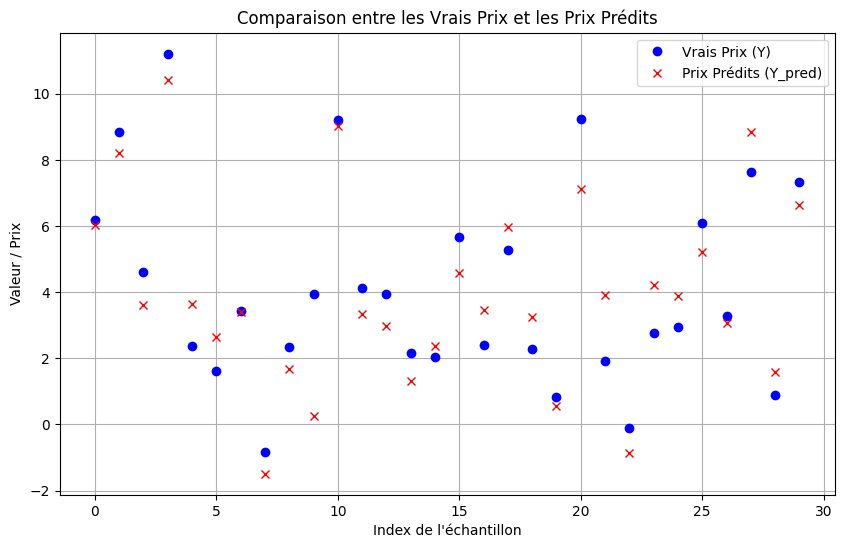

In [ ]:
# 7. Installation de matplotlib et tracé du graphique
%pip install matplotlib

import matplotlib.pyplot as plt

# On calcule les prédictions de notre modèle (Y_pred)
Y_pred = X_b.dot(beta_estime)

# On trace les vraies valeurs vs les prédictions pour les 30 premiers points (pour que ce soit lisible)
plt.figure(figsize=(10, 6))
plt.plot(Y[:30], label="Vrais Prix (Y)", marker='o', color='blue', linestyle='none')
plt.plot(Y_pred[:30], label="Prix Prédits (Y_pred)", marker='x', color='red', linestyle='none')

plt.title("Comparaison entre les Vrais Prix et les Prix Prédits")
plt.xlabel("Index de l'échantillon")
plt.ylabel("Valeur / Prix")
plt.legend()
plt.grid(True)
plt.show()